# CopyKAT: Inference of Genomic Copy Number and Subclonal Structure

**Author**: Ruli Gao  
**Python port**: copykat_py

## Description

A major challenge for single cell RNA sequencing of human tumors is to distinguish cancer cells from stromal cell types, as well as the presence of multiple tumor subclones. CopyKAT (Copy number Karyotyping of Tumors) is a computational tool using integrative Bayesian approaches to identify genome-wide aneuploidy at 5MB resolution in single cells to separate tumor cells from normal cells, and tumor subclones using high-throughput sc-RNAseq data.

The underlying logic of calculating DNA copy numbers from RNAseq data is that gene expression levels of many adjacent genes can be dosed by genomic DNA copy numbers in that region. CopyKAT estimated copy numbers can achieve a high concordance (80%) with the actual DNA copy numbers obtained by whole genome DNA sequencing.

## Step 1: Installation

Install copykat_py from source:
```bash
pip install -e ".[dev]"
```

An example raw UMI matrix from a breast tumor sequenced by 10X 3' RNAseq protocol is included with this package.

## Step 2: Prepare Read Count Input

The only direct input needed is the raw gene expression matrix, with gene IDs in rows and cell names in columns. The gene IDs can be gene symbols or Ensembl IDs. The matrix values are typically UMI counts from high-throughput scRNAseq data.

### Example: Loading data from scanpy/AnnData
```python
import scanpy as sc
adata = sc.read_10x_mtx('path/to/cellranger/outs/filtered_feature_bc_matrix/')
rawmat = adata.to_df().T  # genes x cells
```

In this tutorial, we use the bundled example dataset:

In [1]:
import copykat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Load example UMI count matrix
exp_rawdata = copykat.load_example_data()
print(f"Data shape: {exp_rawdata.shape[0]} genes x {exp_rawdata.shape[1]} cells")
exp_rawdata.iloc[:5, :5]

Data shape: 33694 genes x 302 cells


,AAACCTGCACCTTGTC,AAACGGGAGTCCTCCT,AAACGGGTCCAGAGGA,AAAGATGCAGTTTACG,AAAGCAACAGGAATGC
gene,,,,,
RP11-34P13.3,0,0,0,0,0
FAM138A,0,0,0,0,0
OR4F5,0,0,0,0,0
RP11-34P13.7,0,0,0,0,0
RP11-34P13.8,0,0,0,0,0


## Step 3: Run CopyKAT

Now we have the raw UMI count matrix, we are ready to run CopyKAT.

- **id_type**: `"S"` for gene symbols (default for CellRanger)
- **ngene_chr**: Minimum 5 genes per chromosome for cell filtering
- **win_size**: 25 genes per segment
- **KS_cut**: Segmentation parameter (0.2, higher = fewer breakpoints)
- **distance**: `"euclidean"` for clustering
- **n_cores**: 4 for parallel computation

In [2]:
copykat_test = copykat.copykat(
    rawmat=exp_rawdata,
    id_type="S",
    cell_line="no",
    ngene_chr=5,
    win_size=25,
    KS_cut=0.2,
    sam_name="test",
    distance="euclidean",
    n_cores=4,
)

running copykat v1.1.0
step1: read and filter data ...
33694 genes, 302 cells in raw data
12156 genes past LOW.DR filtering
step 2: annotations gene coordinates ...
step 3: smoothing data with dlm ...
step 4: measuring baselines ...
step 5: segmentation...
step 6: convert to genomic bins...
step 7: adjust baseline ...
step 8: final prediction ...


After this step, we can extract the prediction results and CNA matrix:

In [3]:
pred_test = copykat_test.prediction
CNA_test = copykat_test.CNAmat

print(f"Predictions: {pred_test.shape[0]} cells")
print(f"CNA matrix: {CNA_test.shape[0]} bins x {CNA_test.shape[1]} columns")

Predictions: 302 cells
CNA matrix: 12167 bins x 305 columns


## Step 4: Navigate Prediction Results

Predicted aneuploid cells are inferred as tumor cells; diploid cells are stromal normal cells.

In [4]:
pred_test.head(10)

,cell.names,copykat.pred
0,AAACCTGCACCTTGTC,aneuploid
1,AAACGGGAGTCCTCCT,diploid
2,AAACGGGTCCAGAGGA,aneuploid
3,AAAGATGCAGTTTACG,aneuploid
4,AAAGCAACAGGAATGC,aneuploid
5,AAAGCAATCGGAATCT,aneuploid
6,AAAGTAGAGTGTACTC,diploid
7,AAAGTAGCAGCCTATA,aneuploid
8,AAAGTAGGTACAGTTC,diploid
9,AAAGTAGTCGCATGAT,aneuploid


In [5]:
# Prediction summary
print(pred_test["copykat.pred"].value_counts())

copykat.pred
aneuploid    229
diploid       73
Name: count, dtype: int64


The first 3 columns in the CNA matrix are the genomic coordinates. Rows are 220KB bins in genomic order.

In [6]:
CNA_test.iloc[:5, :5]

,chrom,chrompos,abspos,AAACCTGCACCTTGTC,AAACGGGAGTCCTCCT
0,1,1042457,1042457.0,-0.040678,-0.009802
1,1,1265484,1265484.0,-0.040678,-0.009802
2,1,1519859,1519859.0,-0.040678,-0.009802
3,1,1826619,1826619.0,-0.040678,-0.009802
4,1,2058465,2058465.0,-0.040678,-0.009802


### CNA Heatmap

CopyKAT generates a heatmap for estimated copy numbers. Rows are single cells; columns are 220KB bins in genomic order.

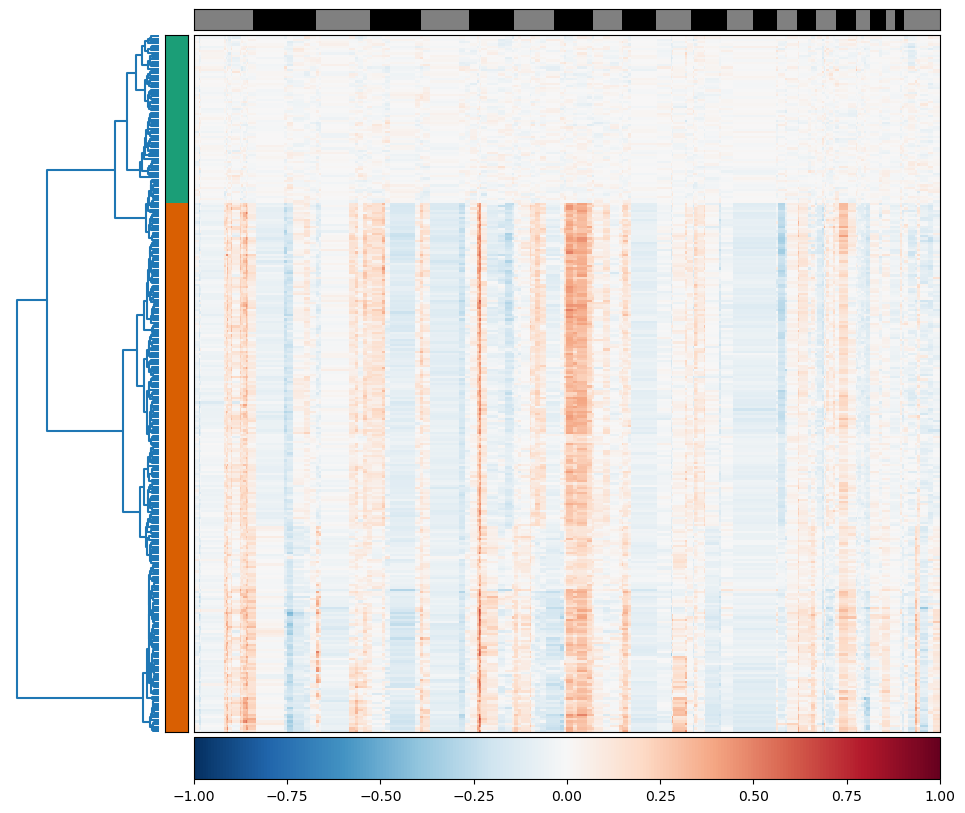

In [7]:
# Prepare color annotations
# Chromosome alternating colors
chr_vals = CNA_test["chrom"].values.astype(int) % 2
chr_colors = np.array(["black" if c == 0 else "grey" for c in chr_vals])

# Prediction colors
pred_dict = dict(zip(pred_test["cell.names"], pred_test["copykat.pred"]))
cell_cols = [c for c in CNA_test.columns if c not in ["chrom", "chrompos", "abspos"]]

pred_colors = []
for cell in cell_cols:
    p = pred_dict.get(cell, "not.defined")
    if "aneuploid" in p:
        pred_colors.append("#D95F02")  # Dark2 orange
    elif "diploid" in p:
        pred_colors.append("#1B9E77")  # Dark2 teal
    else:
        pred_colors.append("grey")

row_side = np.array([pred_colors, pred_colors])
col_side = np.column_stack([chr_colors, chr_colors])

# CNA values
mat = CNA_test[cell_cols].values.T  # cells x bins

# Color breaks matching R
col_breaks = np.concatenate([
    np.linspace(-1, -0.4, 50),
    np.linspace(-0.4, -0.2, 150),
    np.linspace(-0.2, 0.2, 600),
    np.linspace(0.2, 0.4, 150),
    np.linspace(0.4, 1, 50),
])

# Plot heatmap
result = copykat.heatmap3(
    mat,
    row_cluster=True,
    col_cluster=False,
    dist_func="euclidean",
    link_method="ward",
    col_side_colors=col_side,
    row_side_colors=row_side,
    cmap="RdBu_r",
    breaks=col_breaks,
    dendrogram_="row",
    figsize=(12, 10),
    show=True,
)

## Step 5: Define Subpopulations of Aneuploid Tumor Cells

We observed both diploid and aneuploid cells. Next, we extract aneuploid cells (considered tumor cells) and define two copy number subpopulations.

Number of tumor cells: 229


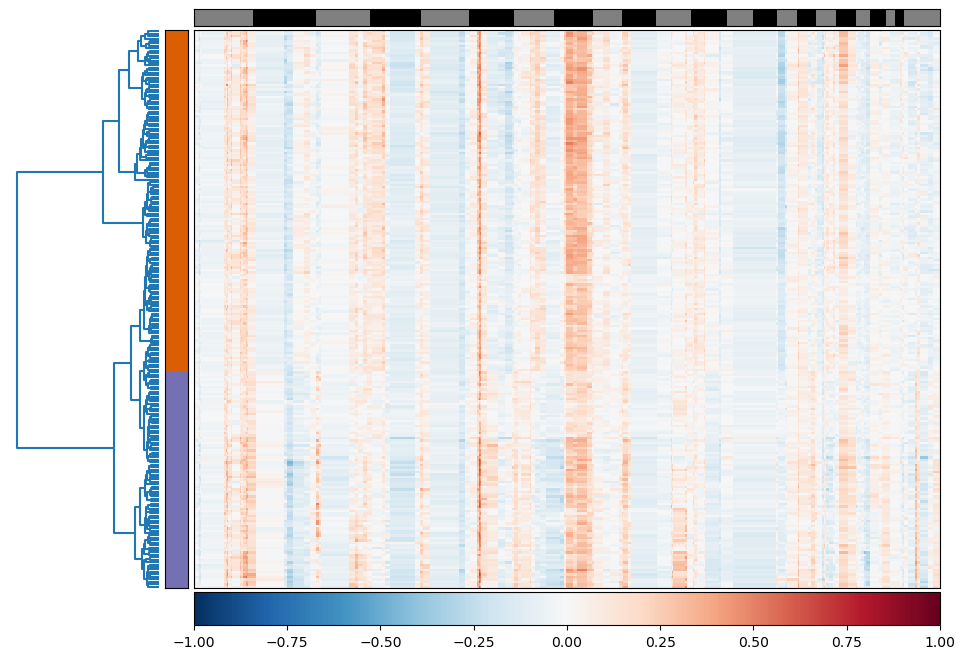


Subclone 1: 140 cells
Subclone 2: 89 cells


In [8]:
# Extract tumor cells
tumor_cells = pred_test.loc[
    pred_test["copykat.pred"].str.contains("aneuploid", na=False), "cell.names"
].tolist()

tumor_cols = [c for c in cell_cols if c in tumor_cells]
tumor_mat = CNA_test[tumor_cols].values

print(f"Number of tumor cells: {len(tumor_cols)}")

# Hierarchical clustering of tumor cells
dist_mat = pdist(tumor_mat.T, metric="euclidean")
hcc = linkage(dist_mat, method="ward")
hc_labels = fcluster(hcc, t=2, criterion="maxclust")

# Subpopulation colors
subpop_colors = ["#D95F02" if l == 1 else "#7570B3" for l in hc_labels]
row_side_sub = np.array([subpop_colors, subpop_colors])

# Plot tumor subclone heatmap
result_sub = copykat.heatmap3(
    tumor_mat.T,
    row_cluster=True,
    col_cluster=False,
    dist_func="euclidean",
    link_method="ward",
    col_side_colors=col_side,
    row_side_colors=row_side_sub,
    cmap="RdBu_r",
    breaks=col_breaks,
    dendrogram_="row",
    figsize=(12, 8),
    show=True,
)

print(f"\nSubclone 1: {(hc_labels == 1).sum()} cells")
print(f"Subclone 2: {(hc_labels == 2).sum()} cells")

Now we have defined two subpopulations with major subclonal differences. We can move forward to compare their gene expression profiles and evaluate gene dosage effects of subclonal copy number changes.

## Useful Annotation Data

CopyKAT also provides useful annotation data:

1. **full_anno** (hg38): Full annotation of 56,051 genes including absolute positions, chr, start, end, Ensembl ID, gene symbol, and G band
2. **DNA_hg20**: Coordinates in hg38 of the 220KB variable bins excluding Y chromosome
3. **cyclegenes**: Cell cycle genes removed from CopyKAT analysis
4. **exp_rawdata**: Example UMI matrix from a breast tumor

In [9]:
# Access annotation data
anno = copykat.load_gene_annotations("hg20")
print(f"Gene annotations (hg38): {anno.shape}")
print(anno.head())

bins = copykat.load_dna_bins()
print(f"\nDNA bins: {bins.shape}")

cycle = copykat.load_cycle_genes()
print(f"\nCell cycle genes: {len(cycle)}")
print(cycle[:10])

Gene annotations (hg38): (56051, 7)
   abspos  chromosome_name  start_position  end_position  ensembl_gene_id  \
0   13139                1           11869         14409  ENSG00000223972   
1   21987                1           14404         29570  ENSG00000227232   
2   17402                1           17369         17436  ENSG00000278267   
3   30331                1           29554         31109  ENSG00000243485   
4   30434                1           30366         30503  ENSG00000284332   

    hgnc_symbol    band  
0       DDX11L1  p36.33  
1        WASH7P  p36.33  
2     MIR6859-1  p36.33  
3  RP11-34P13.3  p36.33  
4     MIR1302-2  p36.33  

DNA bins: (12205, 3)

Cell cycle genes: 1316
['RTEL1', 'ZNF830', 'PCNA', 'GINS2', 'CDC45', 'GINS1', 'DNA2', 'UPF1', 'ZNF259', 'RPA4']
